In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from enum import Enum
from dataclasses import dataclass
import math
from tqdm import tqdm

from tiles import *
from utils import *
import solver as solver_import

0 1.2


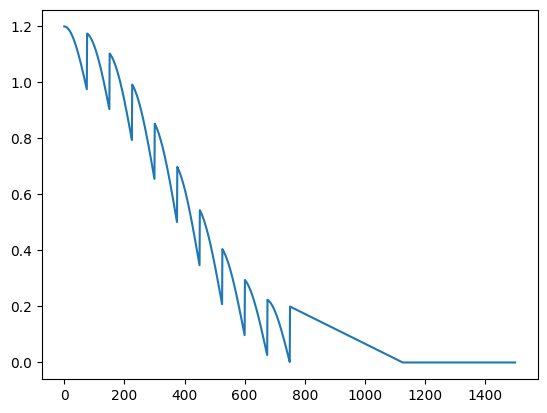

In [7]:
def cawr(x):
    if x<0.5:
        return np.maximum( np.cos(x*2*np.pi/2)**2 + np.cos(x*2*np.pi*5 % (np.pi/2))/5 , 0.001)
    else:
        return max(0.2*(1-(x-0.5)*4),0)
 
g=list(map(cawr, np.arange(0,1501)/1501))
print(min(g),max(g))
plt.plot(g)
plt.show()

In [8]:
BOX_SIZE = 15
INPUT_POS = (14,2)
OUT_POS = (0, 5)
NEG_INF = -500.0

In [ ]:
import importlib
importlib.reload(solver_import) # Fast reaload

solver = solver_import.FactorioSolver(15, DEFAULT_TILE_DATA)

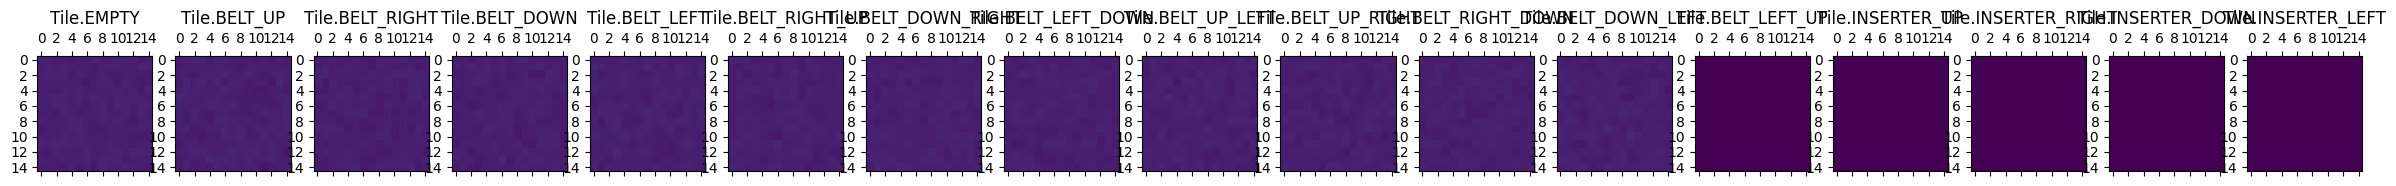

18.065399169921875 14.710394859313965 3355.003662109375 4000000.0 1.2 9.052370296558365e-05 0.0 10
17.38170051574707 13.967268943786621 3414.431884765625 4000000.0 1.195254211395952 8.664980123285204e-05 0.0 9.998917893031615
16.842239379882812 13.344688415527344 3497.5517578125 4000000.0 1.1812036138895554 7.643774006282911e-05 0.0 9.995672040508655
16.44658660888672 12.847448348999023 3599.138427734375 4000000.0 1.1584004881127257 7.407888188026845e-05 0.0 9.990263847374974
16.12373161315918 12.41202163696289 3711.709716796875 4000000.0 1.1277389002006992 6.966674118302763e-05 0.0 9.982695654527964
15.874822616577148 12.052936553955078 3821.885986328125 4000000.0 1.0904162956067986 6.442170706577599e-05 0.0 9.97297073780531
15.688186645507812 11.759641647338867 3928.545166015625 4000000.0 1.047882069742726 6.363406282616779e-05 0.0 9.961093306567074
15.525156021118164 11.493386268615723 4031.770263671875 4000000.0 1.001775333214316 6.222465162863955e-05 0.0 9.947068501873702
15.37915

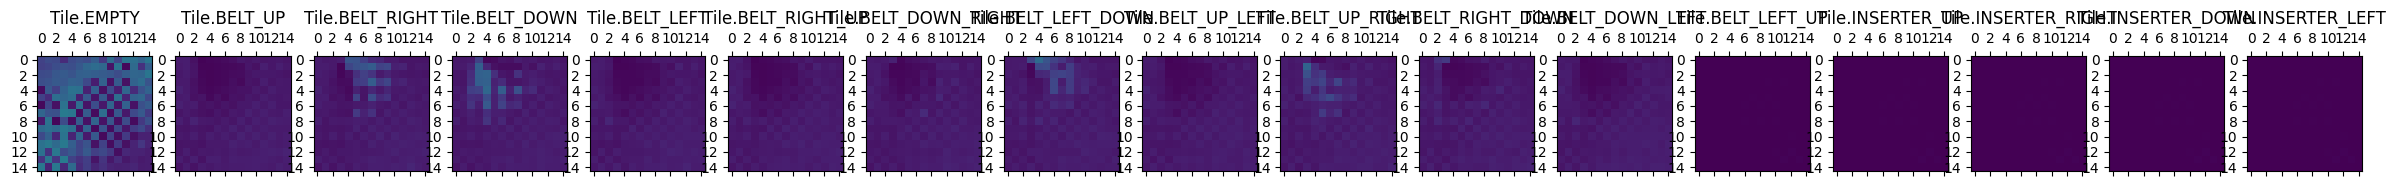

15.175338745117188 10.908271789550781 4267.06689453125 4000000.0 1.1319105135400658 5.488821261678822e-05 0.0 9.89217518362716
15.071895599365234 10.759443283081055 4312.45263671875 4000000.0 1.0991855788139129 5.4216503485804424e-05 0.0 9.86963084340033
14.962265014648438 10.618200302124023 4344.064453125 4000000.0 1.0591864825047423 5.3417916205944493e-05 0.0 9.844978718585855
14.847806930541992 10.481088638305664 4366.71875 4000000.0 1.0132418063112252 5.1658622396644205e-05 0.0 9.818229479678157
14.730533599853516 10.345401763916016 4385.13134765625 4000000.0 0.9629051051244577 5.0309561629546806e-05 0.02666666731238365 9.789394704892363
14.609525680541992 10.205440521240234 4404.08544921875 4000000.0 0.9098886433279474 4.8620771849527955e-05 0.0533333346247673 9.758486875152764
14.486213684082031 10.059565544128418 4426.64794921875 4000000.0 1.0897254113992283 4.575714410748333e-05 0.07111111283302307 9.725519368690536
14.331560134887695 9.881633758544922 4449.9267578125 4000000.0

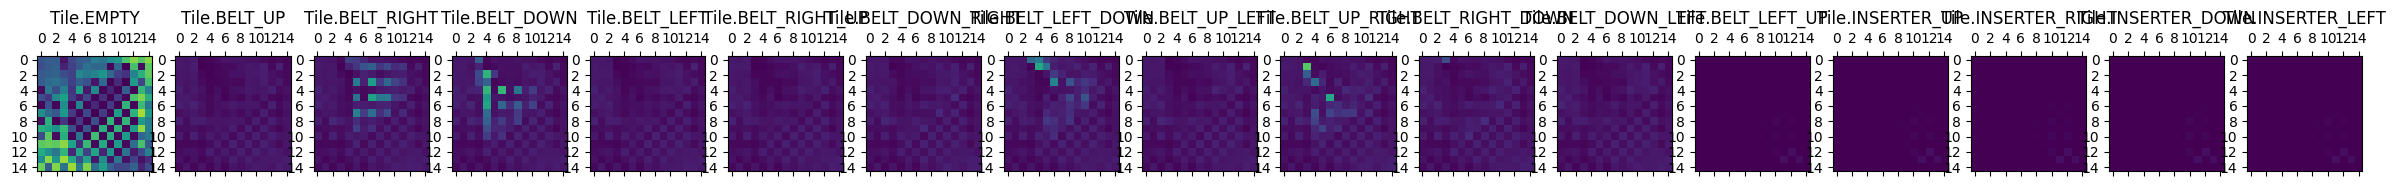

13.974145889282227 9.43603515625 4538.1103515625 4000000.0 0.9413873284208824 4.097039345651865e-05 0.19555555284023285 9.573351210918972
13.83894157409668 9.260825157165527 4578.11669921875 4000000.0 0.8882676264060942 3.946548167732544e-05 0.2177777737379074 9.530316973171777
13.713724136352539 9.093772888183594 4619.95166015625 4000000.0 0.831688932897338 3.6655881558544934e-05 0.24444444477558136 9.485321820398317
13.590997695922852 8.932278633117676 4658.71875 4000000.0 0.987440520159335 3.708995063789189e-05 0.2622222304344177 9.438385228425934
13.442974090576172 8.743341445922852 4699.6328125 4000000.0 0.9628809526551474 3.776609446504153e-05 0.2711111009120941 9.38952751341993
13.292905807495117 8.544352531433105 4748.552734375 4000000.0 0.9295647514683697 3.455321348155849e-05 0.2711111009120941 9.33876982308985
13.138882637023926 8.341554641723633 4797.32763671875 4000000.0 0.8881952094676768 3.122986890957691e-05 0.2844444513320923 9.286134127535856
13.035038948059082 8.1978

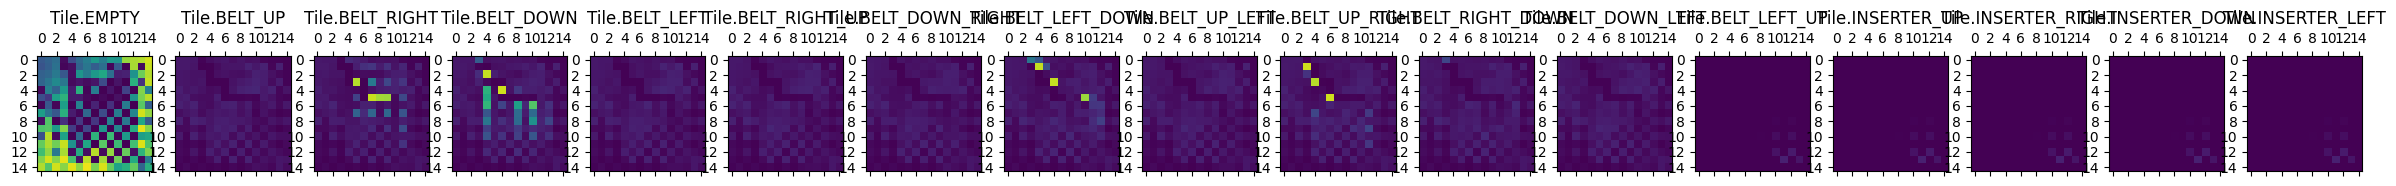

12.700258255004883 7.7595367431640625 4940.7216796875 4000000.0 0.6667801931356635 2.6117304514627904e-05 0.30666667222976685 9.05727893640045
12.64490795135498 7.689365863800049 4955.5419921875 4000000.0 0.8358323430375252 2.5562661903677508e-05 0.30666667222976685 8.995610864646027
12.579137802124023 7.622474670410156 4956.66259765625 4000000.0 0.8046305958434059 3.206832116120495e-05 0.30666667222976685 8.932213321547767
12.496185302734375 7.545973300933838 4950.21240234375 4000000.0 0.7651955759118982 3.168265538988635e-05 0.30666667222976685 8.867113748274939
12.397473335266113 7.457571983337402 4939.90087890625 4000000.0 0.7183873326670605 3.420997381908819e-05 0.30666667222976685 8.80034032270829
12.285137176513672 7.354335308074951 4930.8017578125 4000000.0 0.6653768854698286 3.738003215403296e-05 0.30666667222976685 8.731921947243467
12.124517440795898 7.195857524871826 4928.66015625 4000000.0 0.6075971853655814 3.993138670921326e-05 0.30666667222976685 8.661888236280811
11.86

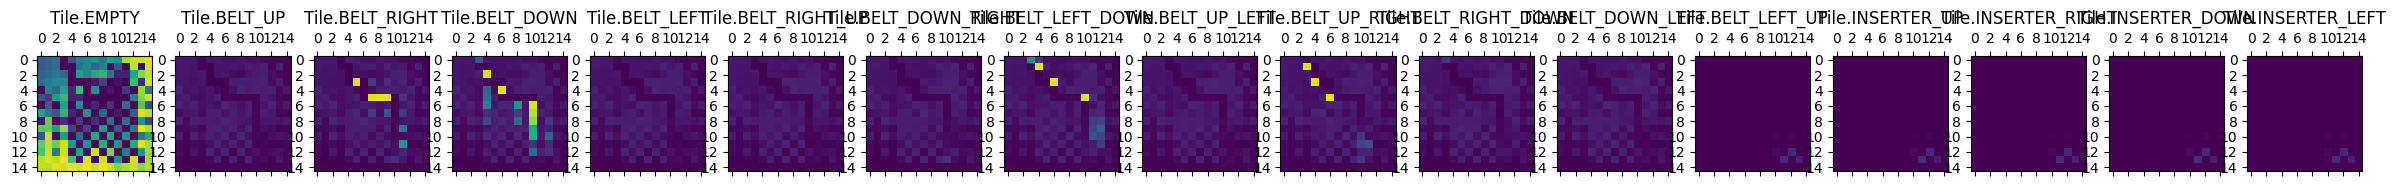

10.188613891601562 5.107524394989014 5081.08984375 4000000.0 0.6317403443758318 4.0726612496655434e-05 0.2844444513320923 8.36621651936562
9.490694046020508 4.330761909484863 5159.93212890625 4000000.0 0.5885838327984224 3.6719975469168276e-05 0.2888889014720917 8.288574353009162
8.829614639282227 3.5823965072631836 5247.21728515625 4000000.0 0.5388159702033146 3.320554969832301e-05 0.2800000011920929 8.209508750963327
8.244270324707031 2.907576560974121 5336.69287109375 4000000.0 0.48373245553025657 2.9565359000116587e-05 0.2800000011920929 8.129053936203688
7.758231163024902 2.335777521133423 5422.453125 4000000.0 0.42486455554679436 2.649093949003145e-05 0.2800000011920929 8.04724473301652
7.372986793518066 1.8736772537231445 5499.30908203125 4000000.0 0.36391452337718183 2.4307251806021668e-05 0.2800000011920929 7.964116551925363
7.07264518737793 1.5095417499542236 5563.103515625 4000000.0 0.529590861800545 2.2729405827703886e-05 0.2800000011920929 7.879705374363828
6.8359746932983

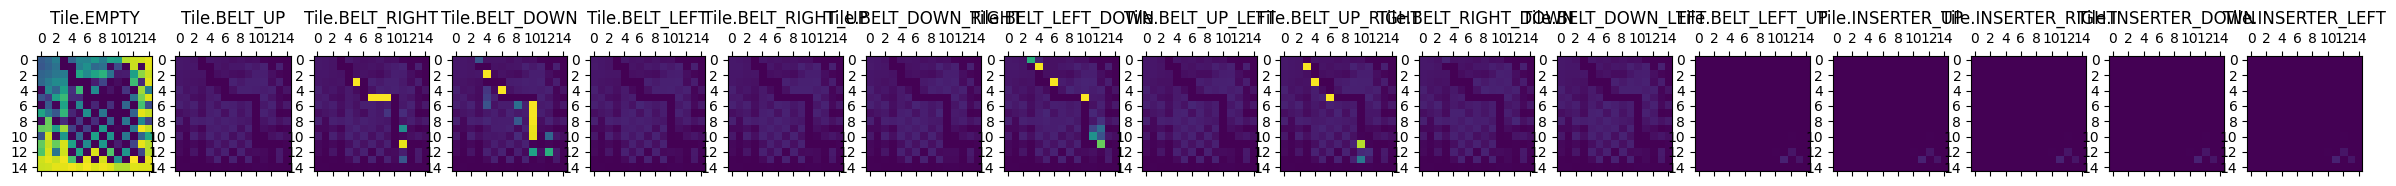

6.346724033355713 0.6944136619567871 5652.31005859375 4000000.0 0.36779172237648755 1.9023384083993733e-05 0.2800000011920929 7.529969431102061
6.2241926193237305 0.5893354415893555 5634.85693359375 4000000.0 0.31317856467398564 1.83344218385173e-05 0.2800000011920929 7.4397018710756395
6.113000392913818 0.5080904960632324 5604.90966796875 4000000.0 0.2557800835297076 1.7707221559248865e-05 0.2800000011920929 7.348378303691027
6.010378360748291 0.4456658363342285 5564.71240234375 4000000.0 0.40349095957150294 1.7117288734880276e-05 0.2800000011920929 7.2560382576956854
5.914905548095703 0.39841508865356445 5516.490234375 4000000.0 0.3813973107192872 1.6573838365729898e-05 0.2800000011920929 7.162721701812504
5.825524806976318 0.3632049560546875 5462.31982421875 4000000.0 0.35146509724788866 1.6062904251157306e-05 0.2800000011920929 7.068469027439638
5.74183464050293 0.3377079963684082 5404.12646484375 4000000.0 0.31432489885586945 1.557256473461166e-05 0.2800000011920929 6.973321031167

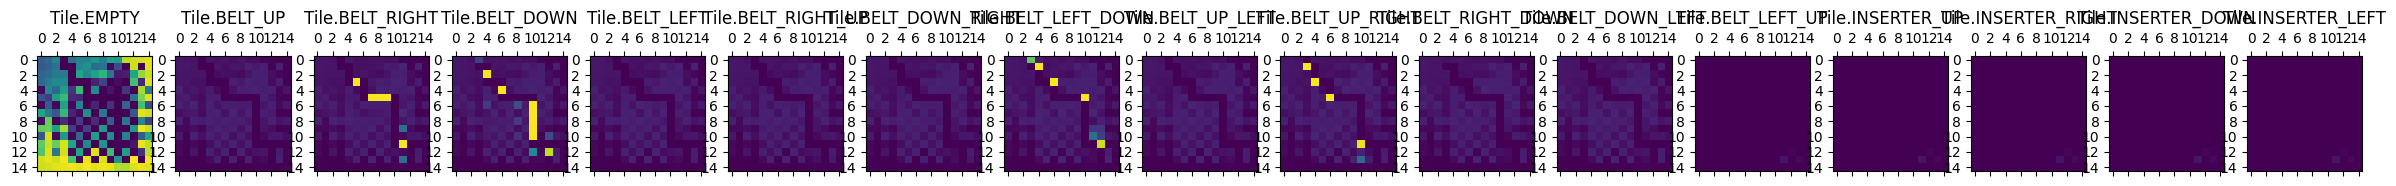

5.461256980895996 0.30075550079345703 5160.50146484375 4000000.0 0.11706390745891557 1.3903886610933114e-05 0.2800000011920929 6.584604947103511
5.40395975112915 0.30185651779174805 5102.10302734375 4000000.0 0.28672464783958596 1.3578825019067153e-05 0.2800000011920929 6.485605226640834
5.35133171081543 0.30525922775268555 5046.072265625 4000000.0 0.26585645377370876 1.3315228898136411e-05 0.2800000011920929 6.38596247267095
5.302938938140869 0.3101820945739746 4992.7568359375 4000000.0 0.2375683827924489 1.3124506040185224e-05 0.2800000011920929 6.285719814841226
5.258394241333008 0.3159818649291992 4942.412109375 4000000.0 0.20263700660863845 1.2954566045664251e-05 0.2800000011920929 6.184920642463091
5.21725606918335 0.3220648765563965 4895.19091796875 4000000.0 0.1621565176573753 1.2811879969376605e-05 0.2844444513320923 6.083608585731279
5.179130554199219 0.3279695510864258 4851.16064453125 4000000.0 0.11749225058864679 1.2686369700531941e-05 0.2844444513320923 5.981827496838818


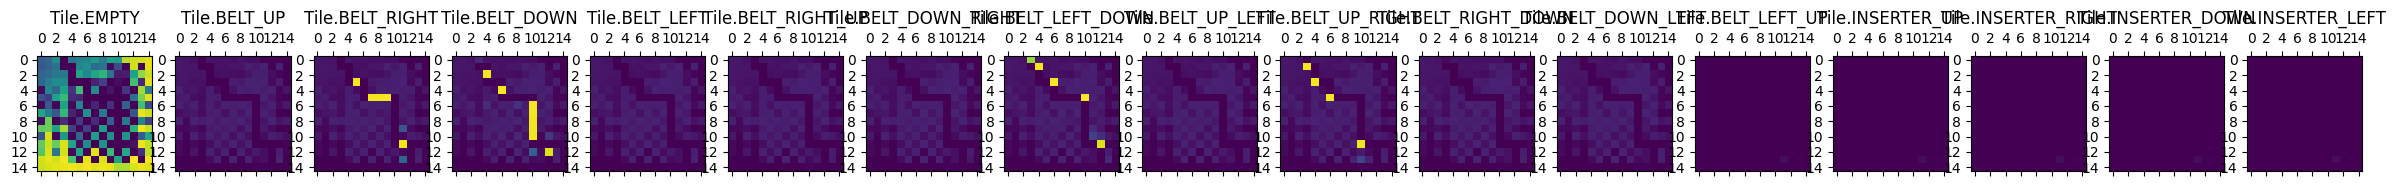

5.051007270812988 0.3444209098815918 4706.5859375 4000000.0 0.19512013128413355 1.2159956895629875e-05 0.2844444513320923 5.570896568126988
5.024120330810547 0.3462638854980469 4677.8564453125 4000000.0 0.1698063127052522 1.2029683603032026e-05 0.2888889014720917 5.4674345378999964
4.9990434646606445 0.3472623825073242 4651.78076171875 4000000.0 0.13839616904018923 1.1898720913450234e-05 0.2888889014720917 5.363770182004717
4.975682258605957 0.34750890731811523 4628.17333984375 4000000.0 0.10210173041545346 1.176258683699416e-05 0.2933333218097687 5.259948370809899
4.95394229888916 0.3471193313598633 4606.82275390625 4000000.0 0.06238114130286812 1.1633836038527079e-05 0.2933333218097687 5.1560140428376915
4.933719635009766 0.34621095657348633 4587.50830078125 4000000.0 0.02087595649390011 1.1520406587806065e-05 0.2933333218097687 5.052012185312317
4.914916515350342 0.34490394592285156 4570.01220703125 4000000.0 0.19735099337748344 1.1428520338085946e-05 0.2933333218097687 4.9479878146

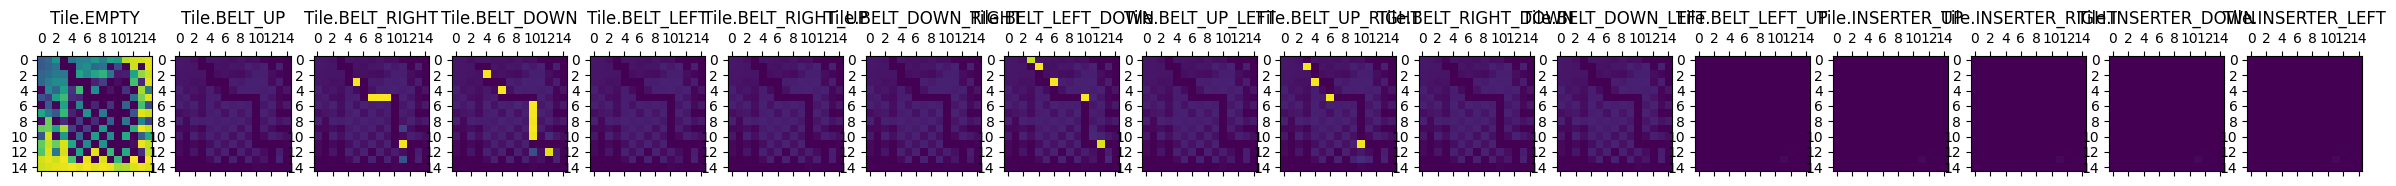

4.851578235626221 0.3375554084777832 4514.0224609375 4000000.0 0.17615894039735097 1.1124296179332305e-05 0.29777777194976807 4.5325654620999964
4.838210582733154 0.33559322357177734 4502.6171875 4000000.0 0.17086092715231793 1.1072406778112054e-05 0.29777777194976807 4.429103431873005
4.825644016265869 0.33368921279907227 4491.95458984375 4000000.0 0.16556291390728478 1.1026156244042795e-05 0.29777777194976807 4.325888510107853
4.813807487487793 0.33188390731811523 4481.92333984375 4000000.0 0.16026490066225163 1.0983671927533578e-05 0.29777777194976807 4.2229653726389715
4.802649021148682 0.33022069931030273 4472.42822265625 4000000.0 0.1549668874172186 1.0941096661554184e-05 0.29777777194976807 4.120378569004069
4.79210901260376 0.32871484756469727 4463.39404296875 4000000.0 0.14966887417218544 1.0899180779233575e-05 0.29777777194976807 4.018172503161176
4.782149314880371 0.32736825942993164 4454.78076171875 4000000.0 0.14437086092715232 1.0859072062885389e-05 0.2933333218097687 3.9

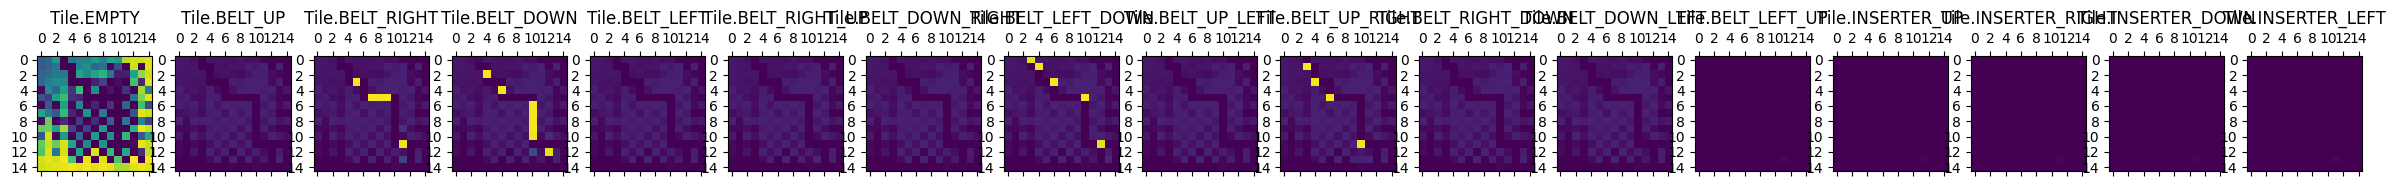

4.747528553009033 0.32375574111938477 4423.7724609375 4000000.0 0.12317880794701984 1.0682794709282462e-05 0.2933333218097687 3.5143947733591605
4.740054607391357 0.32324934005737305 4416.80517578125 4000000.0 0.11788079470198679 1.063417766999919e-05 0.2933333218097687 3.415395052896483
4.733015060424805 0.322878360748291 4410.13671875 4000000.0 0.11258278145695365 1.0584071787889116e-05 0.2933333218097687 3.317081217255967
4.726393699645996 0.32262563705444336 4403.76806640625 4000000.0 0.10728476821192051 1.0534013199503534e-05 0.2933333218097687 3.2194958208722624
4.720162391662598 0.3224668502807617 4397.6953125 4000000.0 0.10198675496688746 1.0484708582225721e-05 0.2933333218097687 3.1226811028803474
4.714303493499756 0.32238149642944336 4391.921875 4000000.0 0.09668874172185432 1.0437142009322997e-05 0.2933333218097687 3.0266789688326146
4.708800315856934 0.3223605155944824 4386.439453125 4000000.0 0.09139072847682117 1.0390881470812019e-05 0.2933333218097687 2.9315309725603576


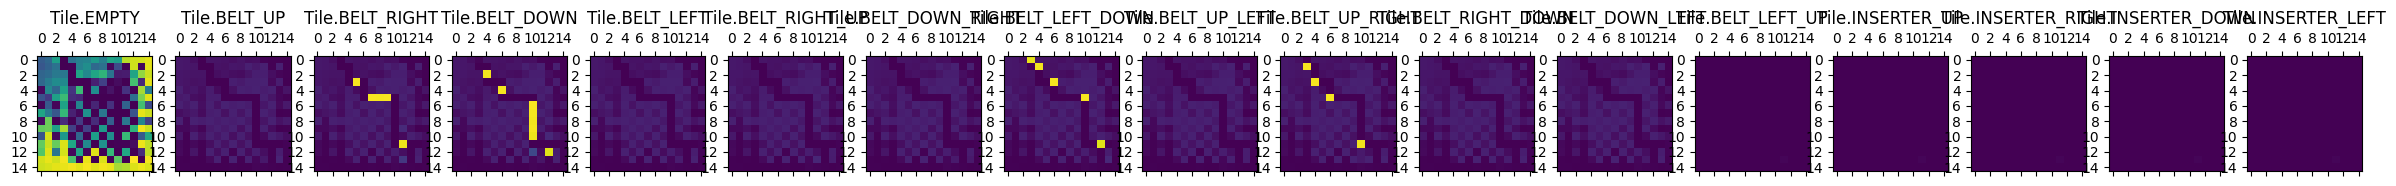

4.6899518966674805 0.32256603240966797 4367.3857421875 4000000.0 0.0701986754966887 1.024267930915812e-05 0.2933333218097687 2.5602981289243547
4.685933589935303 0.32262420654296875 4363.30908203125 4000000.0 0.06490066225165565 1.0214255780738313e-05 0.2933333218097687 2.4700305688979354
4.682164192199707 0.3226761817932129 4359.48779296875 4000000.0 0.059602649006622516 1.0188000487687532e-05 0.2933333218097687 2.3808580878919923
4.6786208152771 0.3227090835571289 4355.91162109375 4000000.0 0.05430463576158937 1.0163957995246165e-05 0.2933333218097687 2.292819283571762
4.675296783447266 0.3227224349975586 4352.57421875 4000000.0 0.049006622516556325 1.0141492566617671e-05 0.2933333218097687 2.2059522628986996
4.672173976898193 0.32271528244018555 4349.45849609375 4000000.0 0.04370860927152318 1.0121020750375465e-05 0.2933333218097687 2.1202946256361686
4.6692423820495605 0.32268762588500977 4346.5546875 4000000.0 0.038410596026490045 1.0102245141752064e-05 0.2933333218097687 2.035883

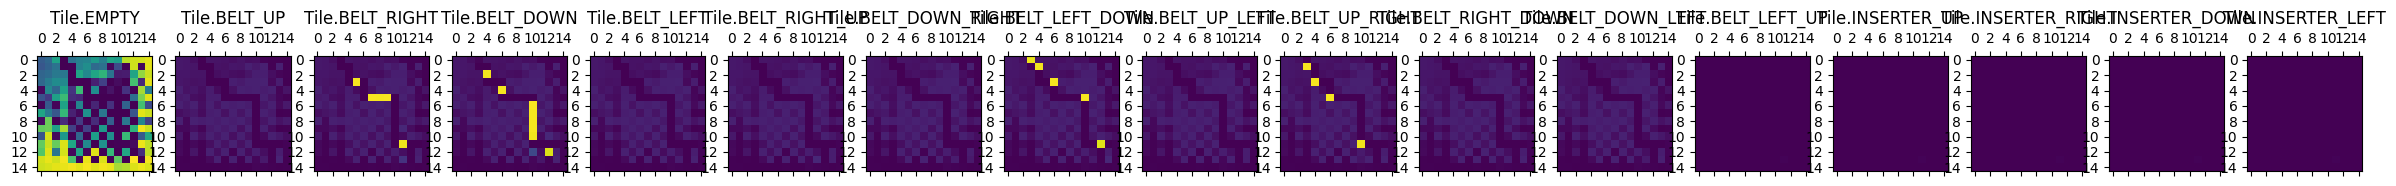

4.659173011779785 0.3223452568054199 4336.82763671875 4000000.0 0.01721854304635766 1.0036039384431206e-05 0.2933333218097687 1.7114256469908344
4.657027244567871 0.3222184181213379 4334.80859375 4000000.0 0.01192052980132452 1.0021847629104741e-05 0.2933333218097687 1.6337834806343772
4.65501594543457 0.3220820426940918 4332.93359375 4000000.0 0.00662251655629138 1.0008467143052258e-05 0.2933333218097687 1.5575983568189986
4.653123378753662 0.3219308853149414 4331.1923828125 4000000.0 0.0013245033112582406 9.995701475418173e-06 0.2933333218097687 1.4829032517260492
4.6513519287109375 0.3217768669128418 4329.57470703125 4000000.0 0 9.983571544580627e-06 0.2933333218097687 1.4097304965930146
4.649689197540283 0.32161617279052734 4328.07275390625 4000000.0 0 9.972063708119094e-06 0.2933333218097687 1.338111763719186
4.648134708404541 0.3214559555053711 4326.6787109375 4000000.0 0 9.9611397672561e-06 0.2933333218097687 1.26807805275653
4.6466779708862305 0.32129383087158203 4325.383789062

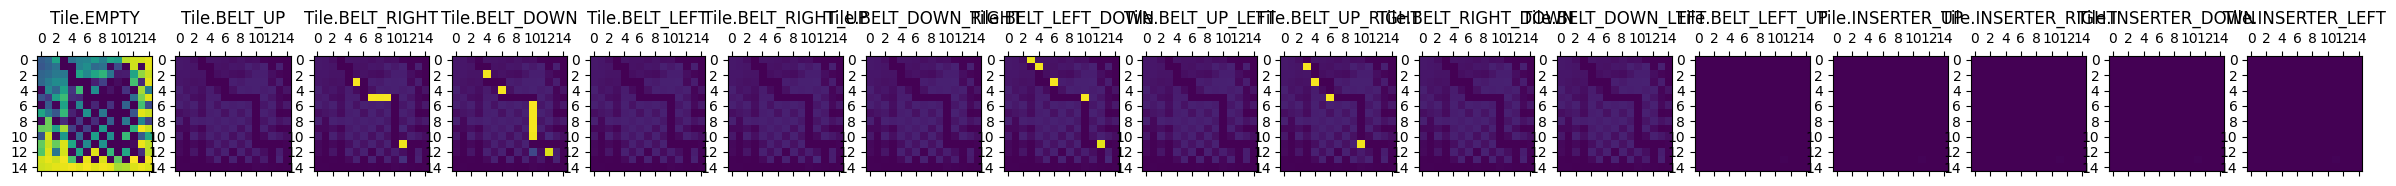

4.642850875854492 0.3208169937133789 4322.03369140625 4000000.0 0 9.924398000293877e-06 0.2933333218097687 1.0043891353539713
4.641748905181885 0.32067394256591797 4321.07470703125 4000000.0 0 9.916941962728743e-06 0.2933333218097687 0.9427210635995475
4.640718936920166 0.32053136825561523 4320.1875 4000000.0 0 9.909969776344951e-06 0.2933333218097687 0.8828091557690282
4.639763355255127 0.32039737701416016 4319.36572265625 4000000.0 0 9.903548743750434e-06 0.2933333218097687 0.8246793442995954
4.6388750076293945 0.3202681541442871 4318.6064453125 4000000.0 0 9.897617928800173e-06 0.2933333218097687 0.7683567902608724
4.6380534172058105 0.3201475143432617 4317.90576171875 4000000.0 0 9.892161870084237e-06 0.2933333218097687 0.7138658724641423
4.637296199798584 0.320035457611084 4317.2607421875 4000000.0 0 9.887159649224486e-06 0.2933333218097687 0.661230176910146
4.636595249176025 0.3199281692504883 4316.6669921875 4000000.0 0 9.882578524411656e-06 0.2933333218097687 0.6104724865800649

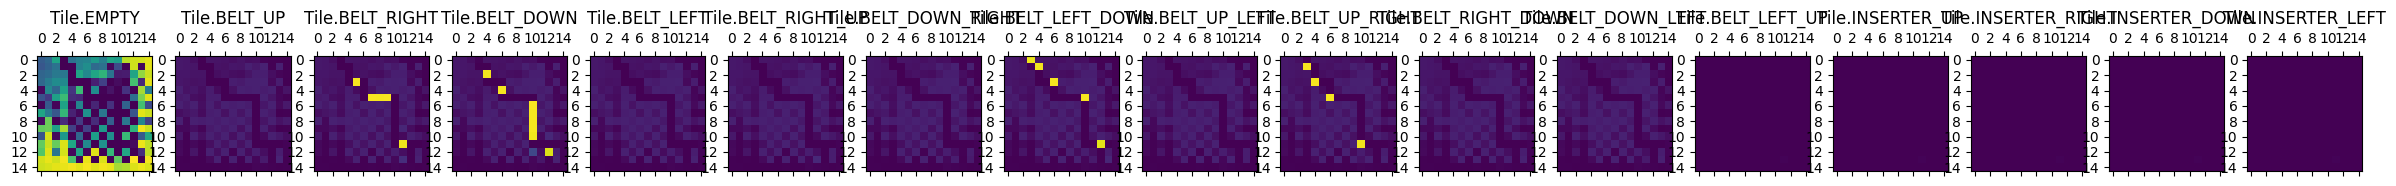

4.634830951690674 0.3196601867675781 4315.17041015625 4000000.0 0 9.871054317045491e-06 0.2933333218097687 0.46968302682822
4.63434362411499 0.31958675384521484 4314.7568359375 4000000.0 0 9.867895641946234e-06 0.2933333218097687 0.42664878908102466
4.633902549743652 0.3195195198059082 4314.3828125 4000000.0 0 9.865053471003193e-06 0.2933333218097687 0.38559409341951423
4.63350248336792 0.3194565773010254 4314.0458984375 4000000.0 0 9.862485057965387e-06 0.2933333218097687 0.3465367100725905
4.633144855499268 0.3194007873535156 4313.74365234375 4000000.0 0 9.860187674348708e-06 0.2933333218097687 0.3094935447469291
4.632822513580322 0.3193478584289551 4313.474609375 4000000.0 0 9.858139492280316e-06 0.2933333218097687 0.274480631309462
4.632541179656982 0.319305419921875 4313.2353515625 4000000.0 0 9.856326869339682e-06 0.2933333218097687 0.24151312484723444
4.632295608520508 0.31927013397216797 4313.025390625 4000000.0 0 9.854749805526808e-06 0.2933333218097687 0.21060529510763631
4.6

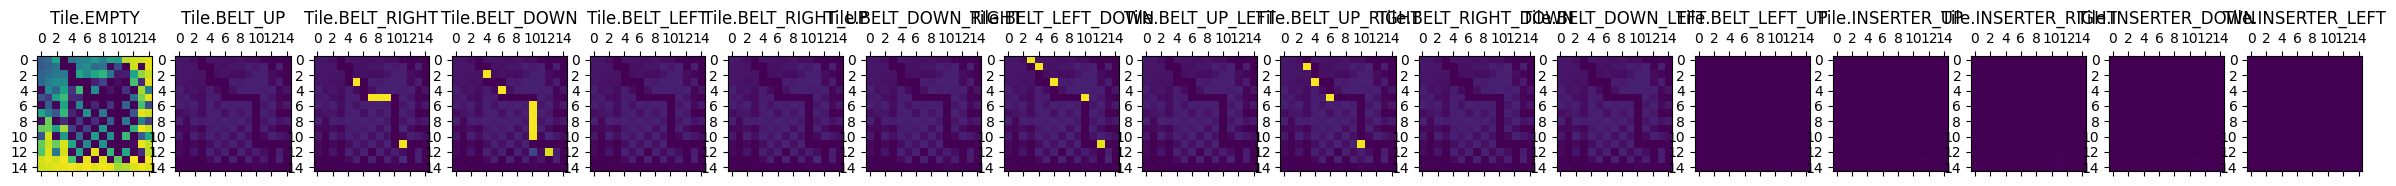

4.631736755371094 0.31918764114379883 4312.548828125 4000000.0 0 9.851152753981296e-06 0.2933333218097687 0.13036915659967055
4.631603717803955 0.3191680908203125 4312.435546875 4000000.0 0 9.850295100477524e-06 0.2933333218097687 0.10782481637284007
4.631489276885986 0.31914663314819336 4312.34228515625 4000000.0 0 9.849587513599545e-06 0.2933333218097687 0.08739801888871462
4.631401538848877 0.3191356658935547 4312.265625 4000000.0 0 9.849024536379147e-06 0.2933333218097687 0.06909760573925501
4.6313300132751465 0.319124698638916 4312.205078125 4000000.0 0 9.848570698522963e-06 0.2933333218097687 0.05293149812629846
4.631275653839111 0.31911659240722656 4312.15869140625 4000000.0 0 9.84823600447271e-06 0.2933333218097687 0.038906693432924605
4.631235599517822 0.3191103935241699 4312.125 4000000.0 0 9.847981345956214e-06 0.2933333218097687 0.027029262194688798
4.63120698928833 0.3191056251525879 4312.10107421875 4000000.0 0 9.847797628026456e-06 0.2933333218097687 0.017304345472035066

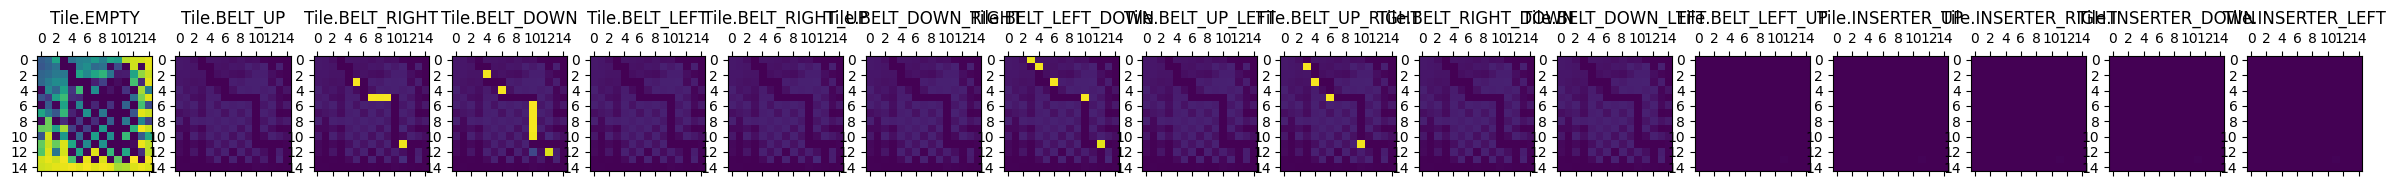

4.631175518035889 0.31910228729248047 4312.0732421875 4000000.0 0 9.847596629697364e-06 0.2933333218097687 0.001082106968385287


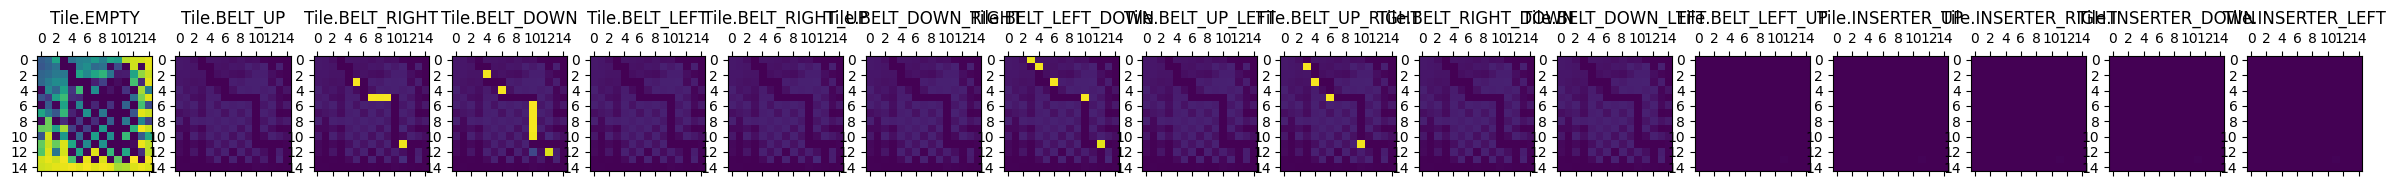

In [34]:
logits = torch.full((BOX_SIZE,BOX_SIZE,len(Tile)), -500.0)
active_tiles = list(range(0,12+1))

logits[:,:,active_tiles] = 5 * torch.randn(BOX_SIZE,BOX_SIZE,len(active_tiles))

logits.requires_grad_()
# solve = smax(solve)

add_tensor = torch.zeros(BOX_SIZE,BOX_SIZE)
add_tensor[0,3] = 100

MAX_ITER = 151
START_TEMP = 100

opt = torch.optim.Adam([logits],lr=10)
# opt = torch.optim.SGD([logits], lr=20,momentum=0.98,nesterov=True)
# opt = torch.optim.RMSprop([logits],lr=5, momentum=0.98)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=MAX_ITER)
for iter in range(MAX_ITER):
    temp = cawr(iter/MAX_ITER)
    # # with torch.no_grad():

    logits_noise = logits + 0.01 * temp * torch.randn_like(logits)
    with torch.no_grad():
        logits_noise[:,:,12::] = -200
    solve = torch.nn.functional.log_softmax(logits_noise/50,dim=-1)
    # solve = gumbel_softmax_log(logits_noise,temperature=5)

    # plot_solve(solve)
    # with torch.no_grad():
    

    # solve = torch.clamp(solve, max=-0.0001)

    if iter%10==0:
        plot_solve(solve)
    items = solver.eval(solve,add_tensor, max_iter=BOX_SIZE*1.8)
    # path_loss = -items[0, 13, :].mean(dim=-1)
    path_loss = -( items[13, 12, :].max(dim=-1)[0] - np.log(100) )
    
    # cost_loss = -( torch.logsumexp(solve[:,:,0], (0,1))/BOX_SIZE**2 )**2 * 1500
    # cost_loss = ( torch.logsumexp(solve[:,:,1::], (0,1,2))/BOX_SIZE**2/(len(Tile)-1))**2 * 1500 * 500 * 3

    inserter_penalty = (logits_noise[:,:,[i.value for i in Tile.INSERTERS()]]**2).mean() * 100 # * 3.5 # 
    belt_penalty = (logits_noise[:,:,[i.value for i in Tile.BELTS()]]**2).mean() * 1

    # inserter_penalty += (solve[:,:,[i.value for i in Tile.INSERTERS()]]).exp().mean() * 7000 * 10 # * 3.5 #  # 
    # belt_penalty += (solve[:,:,[i.value for i in Tile.BELTS()]]).exp().mean() * 1

    logits_penalty = (torch.clamp(logits_noise**2,min=200.0)-200.0).mean() * 0.01 * max(temp,0)
    empty_pos_penalty = -(logits_noise[:,:,0]**2).mean() * 0.0001 * max(1-temp,0)

    dec_penalty = torch.minimum(1-solve,solve-1).mean() * (1.5-max(temp,0.5))
    


    loss = path_loss + (belt_penalty) *0.001 # + empty_pos_penalty + logits_penalty# + dec_penalty
    loss.backward()
    # print(logits.grad)
    opt.step()

    grad_norm = logits.grad.abs().mean().item()
    empty_ratio = (solve[:, :, 0] > -0.5).float().mean().item()
    print(loss.item(), path_loss.item(),belt_penalty.item(),inserter_penalty.item(),temp, grad_norm, empty_ratio, sch.get_last_lr()[0])

    opt.zero_grad()
    sch.step()

plot_solve(solve)

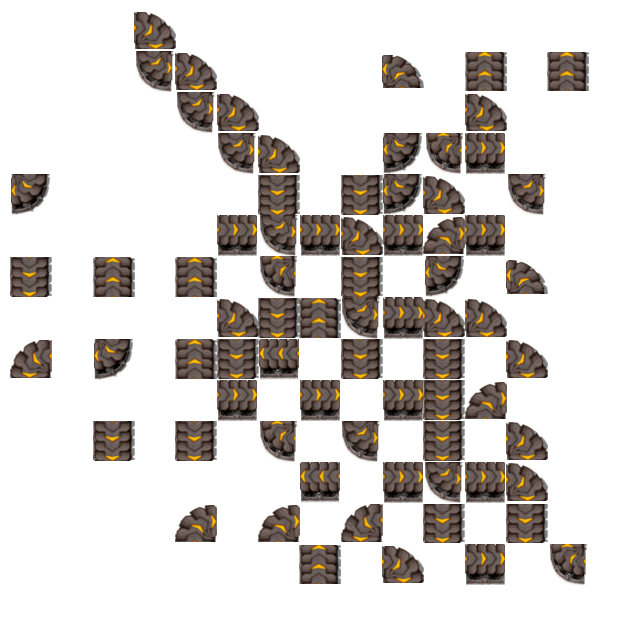

In [33]:
render_solve(solve)